In [2]:
# CARGA DE DATOS #

import pandas as pd
# test comment
# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-003.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:123][desired_columns]
df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18,8.2,1240,610,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,670,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...,...
118,12.8,0.57,15.3,8,1110,550,18,4.18,25,5.04,316,66
119,12.8,0.57,15.3,8.1,1080,550,18,4.23,25,5.69,316,66
120,12.8,0.57,15.4,8.4,1050,520,44,1.96,70,113,146,82
121,12.8,0.57,15.4,8.4,1070,530,44,1.67,70,133,146,82


In [3]:

#ver los que tienen valores nulos o no asignados

#df.isnull().sum()
df.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
#df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)

df_sin_nulos=df.copy()
df_sin_nulos.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
df_sin_nulos.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true
df_sin_nulos.isna().sum()

Temperatura Ambiental (°C)        0
Humedad                           0
Temperatura de la muestra (°C)    0
pH                                0
CE\n(µS/cm)                       0
STD\n(mg/L)                       0
STS\n(mL sed/L)                   0
OD\n(mg/L)                        0
Nivel (cm)                        0
Turbidez (NTU)                    0
Dureza\n(mg CaCO3/L)              0
Cloruros\n(mg Cl-/L)              0
dtype: int64

In [4]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs
0,Temperatura Ambiental (°C),10.40,26.000
1,Humedad,0.36,0.929
2,Temperatura de la muestra (°C),12.80,28.100
3,pH,7.20,8.700
4,CE\n(µS/cm),200.00,1690.000
5,STD\n(mg/L),140.00,840.000
6,STS\n(mL sed/L),0.10,650.000
7,OD\n(mg/L),0.00,9.120
8,Nivel (cm),20.00,70.000
9,Turbidez (NTU),2.68,1000.000


In [5]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




In [139]:
from keras.layers import Input, Dense
from keras.activations import sigmoid
from keras.losses import mse
from keras.models import Model
import numpy as np

vector_size = len(df_sin_nulos.columns)
dataset = np.array(normalizer(df_sin_nulos).astype(np.float16))
encoded_size = 3
# definimos modelo:
input_v = Input(shape=(vector_size, ))
x = Dense(4, activation=sigmoid)(input_v)
encoded = Dense(encoded_size, activation=sigmoid)(x)
x = Dense(4, activation=sigmoid)(encoded)
output = Dense(vector_size, activation=sigmoid)(x)

autoencoder = Model(input_v, output)
autoencoder.compile(optimizer='adam', loss=mse)
autoencoder.summary()


Model: "model_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_22 (InputLayer)       [(None, 12)]              0         
                                                                 
 dense_53 (Dense)            (None, 4)                 52        
                                                                 
 dense_54 (Dense)            (None, 3)                 15        
                                                                 
 dense_55 (Dense)            (None, 4)                 16        
                                                                 
 dense_56 (Dense)            (None, 12)                60        
                                                                 
Total params: 143 (572.00 Byte)
Trainable params: 143 (572.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [157]:
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=500,
    batch_size=120,
    shuffle=True
)


Epoch 1/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 2/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0064
Epoch 3/500
1/1 [==============================] - 0s 5ms/step - loss: 0.0064
Epoch 4/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 5/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 6/500
1/1 [==============================] - 0s 7ms/step - loss: 0.0064
Epoch 7/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 8/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0064
Epoch 9/500
1/1 [==============================] - 0s 6ms/step - loss: 0.0064
Epoch 10/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 11/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 12/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0064
Epoch 13/500
1/1 [==============================] - 0s 3ms/st

In [158]:
generator = Model(encoded, output)
generator.summary()

Model: "model_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_24 (InputLayer)       [(None, 3)]               0         
                                                                 
 dense_55 (Dense)            (None, 4)                 16        
                                                                 
 dense_56 (Dense)            (None, 12)                60        
                                                                 
Total params: 76 (304.00 Byte)
Trainable params: 76 (304.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [159]:
amount = 500
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)


16/16 [==============================] - 0s 941us/step


In [160]:
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,18.401545,0.700010,16.952669,7.782282,818.070984,408.438751,165.378769,3.725350,26.773987,661.174194,132.647736,55.663155
1,17.733665,0.652052,17.432610,7.999857,1102.610352,541.022034,96.279015,1.676021,43.687733,242.223923,150.791016,81.216446
2,19.887957,0.659140,18.123955,7.842927,1273.016724,626.323364,190.071198,1.086598,41.757572,515.555542,146.884979,97.924263
3,14.657212,0.664330,16.025642,8.293268,1057.630249,518.019775,23.427809,5.921619,33.972710,43.386684,175.598389,82.403961
4,19.260933,0.660642,17.798534,8.172361,1748.199585,868.943237,65.678421,2.928619,36.159256,115.960213,204.041687,162.584213
...,...,...,...,...,...,...,...,...,...,...,...,...
495,14.562731,0.542817,16.991041,8.272736,1195.484253,588.977417,28.493019,3.919267,40.944778,44.421505,179.033813,91.889351
496,14.533030,0.549670,16.747843,8.389714,1512.314453,748.889038,17.764009,6.677296,30.944269,25.143200,211.537766,132.143692
497,19.565331,0.701314,17.360483,7.728109,974.015503,482.311066,217.520630,3.057553,26.718716,751.049072,134.438965,69.628700
498,23.522406,0.854914,17.440050,8.005630,1778.041870,880.565063,153.342850,1.692458,36.589386,322.829956,186.054764,169.579468


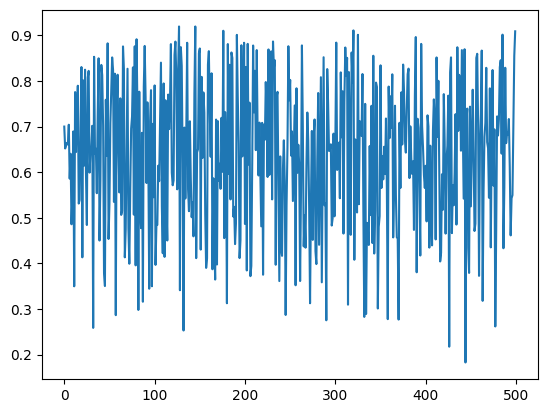

In [161]:
from matplotlib.pyplot import plot
plotable = np.array(gen_df)
plot(plotable.T[1])

In [162]:
min_max_info(df_sin_nulos)

,name,mins,maxs
0,Temperatura Ambiental (°C),10.40,26.000
1,Humedad,0.36,0.929
2,Temperatura de la muestra (°C),12.80,28.100
3,pH,7.20,8.700
4,CE\n(µS/cm),200.00,1690.000
5,STD\n(mg/L),140.00,840.000
6,STS\n(mL sed/L),0.10,650.000
7,OD\n(mg/L),0.00,9.120
8,Nivel (cm),20.00,70.000
9,Turbidez (NTU),2.68,1000.000


In [163]:
min_max_info(gen_df)

,name,mins,maxs
0,Temperatura Ambiental (°C),11.446714,26.114433
1,Humedad,0.182862,0.919440
2,Temperatura de la muestra (°C),15.206548,19.587521
3,pH,7.614431,8.529632
4,CE\n(µS/cm),378.587555,1862.158447
5,STD\n(mg/L),214.106430,925.749939
6,STS\n(mL sed/L),7.640128,387.977692
7,OD\n(mg/L),0.449844,8.411007
8,Nivel (cm),24.311016,59.591812
9,Turbidez (NTU),8.821241,868.823730
